# Inspect `scaffolding_permits_through_2025` — Cyclomedia rows near permits

Summary statistics + sanity checks for `curation/scaffolding_permits_through_2025/cyclomedia_near_permits.parquet`.

Upstream sources:
- `permits.parquet` / `coverage.geojson` — 323,474 DOB scaffold/shed permits with `issue_date <= 2025-12-31` (spanning 1989 → 2025, no lower bound), 80-ft buffered.
- `cyclomedia_near_permits.parquet` — result of `gpd.sjoin(catalog_points, coverage, predicate='within')` over the full 31.5M-row catalog, faces F/B/L/R.

**Naming convention:** `through_2025` in the dir name means the 2025-12-31 cutoff, not a "only permits from 2025" filter — older permits (2024, 2023, ..., 1989) are also included.

Checks here establish that the curated parquet is well-formed and faithfully reflects the catalog × coverage intersection.

In [1]:
from __future__ import annotations

import json
import os
import random
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from PIL import Image

from dagspaces.common.cyclomedia_catalog import CyclomediaCatalog

CURATION = Path('/share/pierson/matt/mllmsci/curation/scaffolding_permits_through_2025')
NEAR = CURATION / 'cyclomedia_near_permits.parquet'
PERMITS = CURATION / 'permits.parquet'
COVERAGE = CURATION / 'coverage.geojson'
MANIFEST = CURATION / 'cyclomedia_materialize_manifest.json'

random.seed(0)
np.random.seed(0)

## 1. Load and cross-check against manifest

In [2]:
df = pl.read_parquet(NEAR)
manifest = json.loads(MANIFEST.read_text())

print(f'rows: {df.height:,}   columns: {len(df.columns)}')
print(f'file size: {os.path.getsize(NEAR) / 1024**2:.1f} MB')
print(f'manifest rows: {manifest["rows"]:,}  (match: {df.height == manifest["rows"]})')
print(f'manifest built_at: {manifest["built_at"]}')
print(f'manifest elapsed: {manifest["elapsed_s"]:.1f}s')
print(f'backend: {manifest["spatial_join_backend"]}')
print()
print('columns:', df.columns)

rows: 6,296,458   columns: 52
file size: 191.3 MB
manifest rows: 6,296,458  (match: True)
manifest built_at: 2026-04-21T19:28:49.848708+00:00
manifest elapsed: 30.9s
backend: geopandas.sjoin (STRtree via GEOS)

columns: ['sample_id', 'recording_id', 'face', 'image_path', 'group', 'borough', 'latitude', 'longitude', 'geom_wkb', 'statePlaneX', 'statePlaneY', 'locationSRS', 'latitudePrecision', 'longitudePrecision', 'height', 'heightPrecision', 'groundLevelOffset', 'heightSystem', 'recordedAt', 'recorderDirection', 'yawDegrees', 'yawPrecisionDegrees', 'orientation', 'orientationPrecision', 'bearing', 'productType', 'panoramaTileSchema', 'tileSchema', 'hasDepthMap', 'isAuthorized', 'manifest_zoom', 'manifest_tile_px', 'manifest_tile_schema', 'manifest_name_version', 'manifest_mode', 'manifest_checkpoint', 'manifest_no_tiles', 'face_elapsed_s', 'face_used_render', 'depthmap_present', 'depthmap_used_render', 'depthmap_render_size', 'depthmap_rgb_render_size', 'depthmap_downsample_factor', 'd

## 2. Summary statistics — per dataset × year × face

In [3]:
by_dataset = df.group_by('dataset').len().sort('dataset')
by_year = df.group_by(['dataset', 'year']).len().sort(['dataset', 'year'])
by_face = df.group_by(['dataset', 'face']).len().sort(['dataset', 'face'])

print('=== by dataset ===')
print(by_dataset)
print()
print('=== by (dataset, year) ===')
print(by_year)
print()
print('=== by (dataset, face) ===')
print(by_face)

=== by dataset ===
shape: (5, 2)
┌───────────────────┬─────────┐
│ dataset           ┆ len     │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ bronx_2025_1k     ┆ 1115935 │
│ brooklyn_2025_1k  ┆ 2132699 │
│ manhattan_2025_1k ┆ 1617356 │
│ queens_2025_1k    ┆ 1315691 │
│ si_2025_1k        ┆ 114777  │
└───────────────────┴─────────┘

=== by (dataset, year) ===
shape: (7, 3)
┌───────────────────┬──────┬─────────┐
│ dataset           ┆ year ┆ len     │
│ ---               ┆ ---  ┆ ---     │
│ str               ┆ i64  ┆ u32     │
╞═══════════════════╪══════╪═════════╡
│ bronx_2025_1k     ┆ 2025 ┆ 1115935 │
│ brooklyn_2025_1k  ┆ 2025 ┆ 2132699 │
│ manhattan_2025_1k ┆ 2017 ┆ 530053  │
│ manhattan_2025_1k ┆ 2025 ┆ 1087303 │
│ queens_2025_1k    ┆ 2017 ┆ 273971  │
│ queens_2025_1k    ┆ 2025 ┆ 1041720 │
│ si_2025_1k        ┆ 2025 ┆ 114777  │
└───────────────────┴──────┴─────────┘

=== by (dataset, face) ===
shape: (20, 3)
┌──────────────────┬───

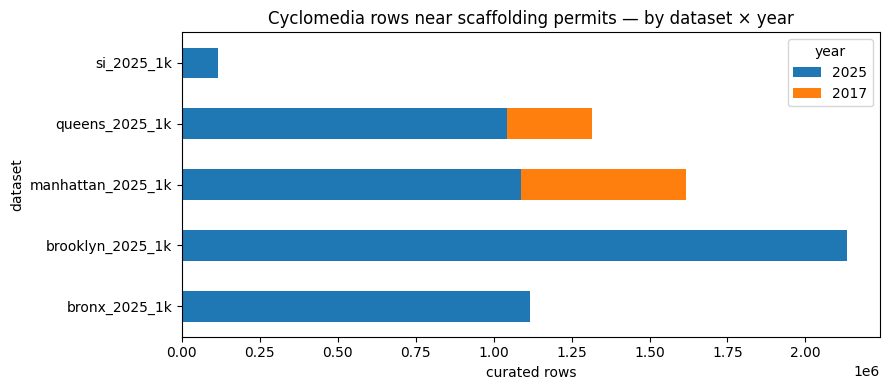

In [4]:
# Stacked bar: dataset × year
pivot = (
    df.group_by(['dataset', 'year']).len()
      .pivot(values='len', index='dataset', on='year')
      .fill_null(0)
      .sort('dataset')
)
pivot_pd = pivot.to_pandas().set_index('dataset')
fig, ax = plt.subplots(figsize=(9, 4))
pivot_pd.plot(kind='barh', stacked=True, ax=ax)
ax.set_xlabel('curated rows')
ax.set_title('Cyclomedia rows near scaffolding permits — by dataset × year')
ax.legend(title='year')
plt.tight_layout()
plt.show()

## 3. Temporal distribution

Based on `recordedAt` (drive-date of the Cyclomedia pass).

recordedAt range: 2025-03-04 08:08:58.660000-05:00 → 2025-11-05 11:01:48.120000-05:00


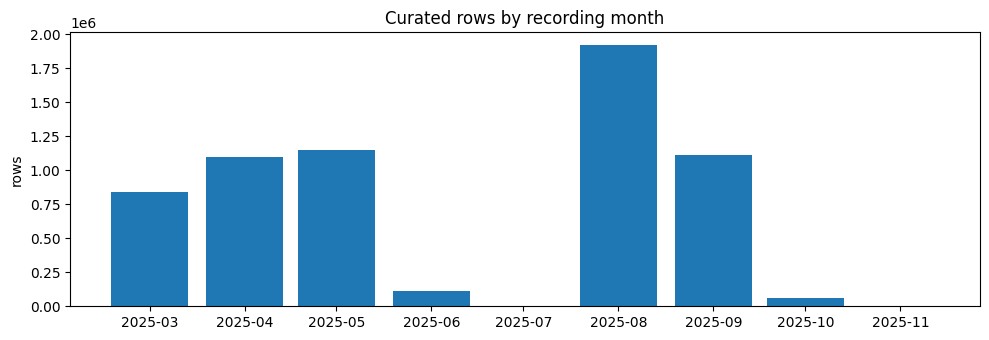

In [5]:
by_month = (
    df.with_columns(pl.col('recordedAt').dt.truncate('1mo').alias('month'))
      .group_by('month').len()
      .sort('month')
)
mp = by_month.to_pandas()
print(f'recordedAt range: {df["recordedAt"].min()} → {df["recordedAt"].max()}')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(mp['month'], mp['len'], width=25)
ax.set_ylabel('rows')
ax.set_title('Curated rows by recording month')
plt.tight_layout()
plt.show()

## 4. Data quality checks

Nulls, face set, NYC bbox, random `image_path` existence + JPEG decode.

In [6]:
NYC_BBOX = {'lat_min': 40.4, 'lat_max': 41.0, 'lon_min': -74.3, 'lon_max': -73.6}

# Uniqueness is scoped per-dataset — a recording that sits on a borough
# bbox edge can legitimately appear in both datasets (catalog validation warn
# check #11), so the true per-row key is (dataset, sample_id), not sample_id alone.
rows_per_ds_key = int(df.select(['dataset', 'sample_id']).unique().height)

checks = {
    'rows': df.height,
    'null_sample_id': df['sample_id'].null_count(),
    'null_recording_id': df['recording_id'].null_count(),
    'null_image_path': df['image_path'].null_count(),
    'null_lat_lon': int(df.filter(pl.col('latitude').is_null() | pl.col('longitude').is_null()).height),
    'face_in_FBLR': int(df.filter(pl.col('face').is_in(['F','B','L','R'])).height),
    'lat_in_nyc_bbox': int(df.filter(
        pl.col('latitude').is_between(NYC_BBOX['lat_min'], NYC_BBOX['lat_max'])
    ).height),
    'lon_in_nyc_bbox': int(df.filter(
        pl.col('longitude').is_between(NYC_BBOX['lon_min'], NYC_BBOX['lon_max'])
    ).height),
    'unique_(dataset, sample_id)': rows_per_ds_key,
    'unique_sample_ids (cross-dataset)': df['sample_id'].n_unique(),
}
for k, v in checks.items():
    flag = ''
    if k.startswith('null_') and v != 0:
        flag = '  <-- NON-ZERO'
    if k in {'face_in_FBLR', 'lat_in_nyc_bbox', 'lon_in_nyc_bbox', 'unique_(dataset, sample_id)'} and v != checks['rows']:
        flag = f'  <-- {checks["rows"] - v} rows off'
    print(f'  {k}: {v:,}{flag}')

cross_ds_dupes = checks['rows'] - checks['unique_sample_ids (cross-dataset)']
print(f'\nCross-dataset sample_id duplicates: {cross_ds_dupes:,} rows')
print('  (same (recording_id, face) landing in two adjacent-borough datasets — catalog warn check #11)')
print('  Downstream consumers wanting a single copy per recording should .unique(["sample_id"]) at read time.')

  rows: 6,296,458
  null_sample_id: 0
  null_recording_id: 0
  null_image_path: 0
  null_lat_lon: 0
  face_in_FBLR: 6,296,458
  lat_in_nyc_bbox: 6,296,458
  lon_in_nyc_bbox: 6,296,458
  unique_(dataset, sample_id): 6,296,458
  unique_sample_ids (cross-dataset): 6,272,809

Cross-dataset sample_id duplicates: 23,649 rows
  (same (recording_id, face) landing in two adjacent-borough datasets — catalog warn check #11)
  Downstream consumers wanting a single copy per recording should .unique(["sample_id"]) at read time.


In [7]:
# Spot-check: 20 random image paths exist and open as JPEG
sample = df.sample(n=20, seed=0).select(['sample_id', 'image_path']).to_dicts()
missing = []
bad = []
sizes = []
for r in sample:
    p = r['image_path']
    if not os.path.isfile(p):
        missing.append(p)
        continue
    try:
        with Image.open(p) as im:
            im.verify()
            sizes.append(os.path.getsize(p))
    except Exception as exc:
        bad.append((p, str(exc)))

print(f'sampled={len(sample)}  ok={len(sample) - len(missing) - len(bad)}  missing={len(missing)}  bad={len(bad)}')
if sizes:
    print(f'file size bytes — min {min(sizes):,}  median {int(np.median(sizes)):,}  max {max(sizes):,}')
for p in missing[:3]:
    print('  missing:', p)
for p, e in bad[:3]:
    print('  bad:', p, '-', e)

sampled=20  ok=20  missing=0  bad=0
file size bytes — min 183,172  median 221,015  max 319,221


## 5. Spatial sanity — sample of curated points over coverage outline

Visual check that curated points land inside the coverage mask. A 50k random sample is enough to show the geographic distribution.

coverage: 5388 polygon features


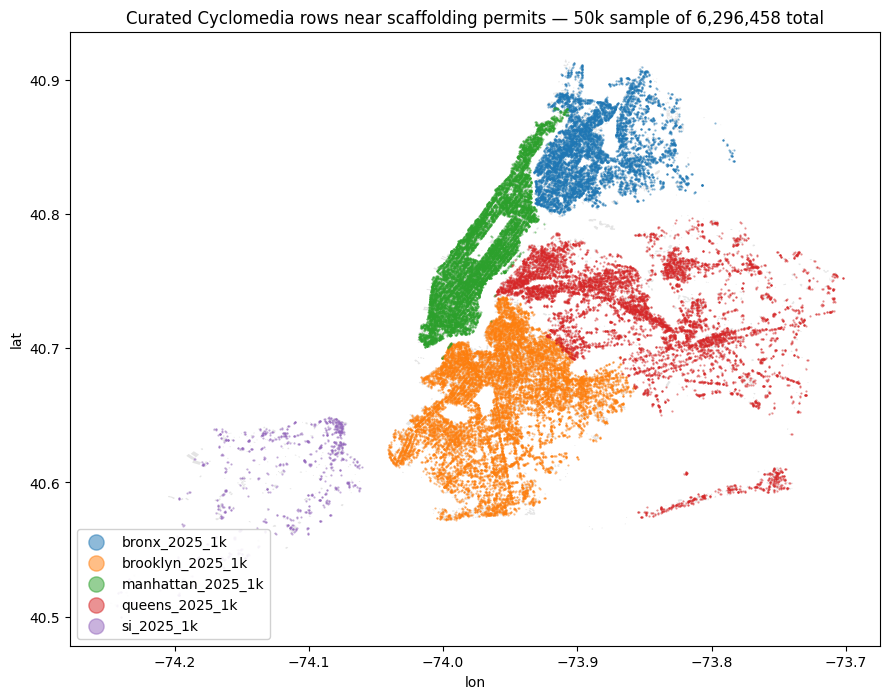

In [8]:
coverage = gpd.read_file(COVERAGE)
print(f'coverage: {len(coverage)} polygon features')

sample = df.sample(n=min(50_000, df.height), seed=0).select(['dataset', 'latitude', 'longitude']).to_pandas()
color_map = {
    'bronx_2025_1k': '#1f77b4',
    'brooklyn_2025_1k': '#ff7f0e',
    'manhattan_2025_1k': '#2ca02c',
    'queens_2025_1k': '#d62728',
    'si_2025_1k': '#9467bd',
}

fig, ax = plt.subplots(figsize=(9, 9))
coverage.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.6)
for ds, sub in sample.groupby('dataset'):
    ax.scatter(sub['longitude'], sub['latitude'], s=0.3, c=color_map.get(ds, 'k'), alpha=0.5, label=ds)
ax.set_aspect('equal')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.set_title(f'Curated Cyclomedia rows near scaffolding permits — 50k sample of {df.height:,} total')
ax.legend(markerscale=20, loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Catalog hit rate — curated rows / full-catalog F/B/L/R rows

Per dataset: what fraction of the catalog's horizontal-face rows landed near a scaffold permit?

In [9]:
cat = CyclomediaCatalog()
catalog_sizes = {}
for ds in sorted(df['dataset'].unique().to_list()):
    lf = cat.scan(datasets=[ds]).filter(pl.col('face').cast(pl.Utf8).is_in(['F','B','L','R']))
    catalog_sizes[ds] = int(lf.select(pl.len()).collect().item())

curated_sizes = {r['dataset']: r['len'] for r in df.group_by('dataset').len().to_dicts()}

rows = [
    {'dataset': ds,
     'catalog_FBLR': catalog_sizes[ds],
     'curated': curated_sizes.get(ds, 0),
     'hit_rate_pct': 100.0 * curated_sizes.get(ds, 0) / catalog_sizes[ds] if catalog_sizes[ds] else float('nan')}
    for ds in sorted(catalog_sizes)
]
import pandas as pd
print(pd.DataFrame(rows).to_string(index=False))

total_cat = sum(catalog_sizes.values())
total_cur = sum(curated_sizes.values())
print(f'\nOverall: {total_cur:,} / {total_cat:,} = {100*total_cur/total_cat:.2f}% of F/B/L/R catalog rows fall near a scaffolding permit.')

          dataset  catalog_FBLR  curated  hit_rate_pct
    bronx_2025_1k       3156817  1115935     35.350006
 brooklyn_2025_1k       5051728  2132699     42.217218
manhattan_2025_1k       2161679  1617356     74.819434
   queens_2025_1k       7750543  1315691     16.975469
       si_2025_1k       2902329   114777      3.954652

Overall: 6,296,458 / 21,023,096 = 29.95% of F/B/L/R catalog rows fall near a scaffolding permit.


## 7. Per-recording density

Each Cyclomedia `recording_id` has up to 4 horizontal faces. How many full recordings landed in the curated set vs. partial ones?

In [10]:
by_rec = df.group_by('recording_id').agg(pl.col('face').n_unique().alias('n_faces'))
print(f'unique recordings in curated set: {by_rec.height:,}')
print()
print(by_rec.group_by('n_faces').len().sort('n_faces'))

# How many recordings have all 4 horizontal faces?
all4 = int(by_rec.filter(pl.col('n_faces') == 4).height)
print(f'\nRecordings with all 4 F/B/L/R faces: {all4:,} ({100*all4/by_rec.height:.2f}% of curated recordings)')

unique recordings in curated set: 1,570,094

shape: (4, 2)
┌─────────┬─────────┐
│ n_faces ┆ len     │
│ ---     ┆ ---     │
│ u32     ┆ u32     │
╞═════════╪═════════╡
│ 1       ┆ 147     │
│ 2       ┆ 1083    │
│ 3       ┆ 4960    │
│ 4       ┆ 1563904 │
└─────────┴─────────┘

Recordings with all 4 F/B/L/R faces: 1,563,904 (99.61% of curated recordings)


## Summary

If every check above shows clean numbers — no nulls in identity/path/coord columns, 100% of rows in `{F,B,L,R}`, all rows in NYC bbox, `unique_(dataset, sample_id) == rows` (per-dataset uniqueness), sampled JPEGs open, curated points visually inside coverage — the sub-dataset is cleared for downstream use.

Cross-dataset `sample_id` duplicates (a recording sitting on a borough bbox edge shows up in two datasets) are **expected** — this inherits from catalog validation warn check #11. Downstream pipelines that want a single copy per recording should `.unique(['sample_id'])` at read time.

See `docs/plans/scaffolding-permits-curation.md` and `vault/context/wiki/scaffolding-permits-curation.md` for the full design rationale and validation history.